LAB-1 AND GATE

In [1]:
!pip install torchvision seaborn scikit-learn

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_IN.UTF-8)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 14.2 MB/s eta 0:00:00a 0:00:01


In [2]:
import numpy as np

class Perceptron:
    def __init__(self,inputs):
        self.weights=np.zeros(inputs)
        self.bias=0.0
    
    def activation_function(self,X):
        return 1 if X>=0 else 0
        # returns 0 for negative and 0  ,, returns 1 for positive numbers
            
    def predict(self,inputs):
        weighted_sum=np.dot(inputs,self.weights)+ self.bias 

        # Y_pred = inputs . W + b
        
        return self.activation_function(weighted_sum)
        # convert the value to 1 or 0 based on the value

    def train(self,train_inputs,labels,learning_rate=0.1,epochs=10):
        for epoch in range(0,epochs):
            
            
            print(f"Epoch { epoch } ")

            for inputs,label in zip(train_inputs,labels):
                prediction=self.predict(inputs) # predict the output

                error =label - prediction # check the difference between actual and predicted values

                self.weights+=learning_rate*error*inputs # update the weights 
                self.bias+=learning_rate*error # update the bias
                

        print(f"Training complete  weights : {self.weights} , Bias : {self.bias}")
    
    


In [3]:
# AND GATE IMPLEMENTATION

# why do we do this AND GATE SPECIFICALLY ?

# well known output 

p = Perceptron(2)

train_inputs=np.array([
    [1,1],
    [1,0],
    [0,1],
    [0,0]
])

labels = np.array([1,0,0,0])

p.train(train_inputs,labels,learning_rate=0.1,epochs=10)

print("\n Test the trained perceptron \n")

print(f" 0 and 0 = ",p.predict(np.array([0,1])))


Epoch 0 
Epoch 1 
Epoch 2 
Epoch 3 
Epoch 4 
Epoch 5 
Epoch 6 
Epoch 7 
Epoch 8 
Epoch 9 
Training complete  weights : [0.1 0.2] , Bias : -0.20000000000000004

 Test the trained perceptron 

 0 and 0 =  0


LAB-2

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

def get_model(activation):
    act = nn.ReLU() if activation == 'relu' else nn.Sigmoid()
    return nn.Sequential(nn.Linear(2,4), act, nn.Linear(4,1), nn.Sigmoid())

def train(activation, lr, epochs=1000):
    model = get_model(activation)
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    for epoch in range(epochs):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        preds = (model(X) >= 0.5).float()
        acc = (preds == y).float().mean().item() * 100
    print(f"{activation.upper()} | LR={lr} | Loss={loss.item():.4f} | Acc={acc:.1f}%")

train('sigmoid', 0.01)
train('sigmoid', 0.1)
train('relu', 0.01)
train('relu', 0.1)

SIGMOID | LR=0.01 | Loss=0.6930 | Acc=50.0%
SIGMOID | LR=0.1 | Loss=0.6924 | Acc=75.0%
RELU | LR=0.01 | Loss=0.6498 | Acc=75.0%
RELU | LR=0.1 | Loss=0.0575 | Acc=100.0%


LAB 3 XOR GATE 

Trial 1 | LR=0.01 Units=32 Batch=32 Dropout=0.0 | Loss=0.5449 | Acc=100.0% | Overfit=No
Trial 2 | LR=0.01 Units=64 Batch=32 Dropout=0.2 | Loss=0.4302 | Acc=100.0% | Overfit=No
Trial 3 | LR=0.1 Units=64 Batch=64 Dropout=0.3 | Loss=0.0384 | Acc=100.0% | Overfit=No
Trial 4 | LR=0.1 Units=128 Batch=16 Dropout=0.4 | Loss=0.0062 | Acc=100.0% | Overfit=No
Trial 5 | LR=0.001 Units=128 Batch=64 Dropout=0.5 | Loss=0.7067 | Acc=50.0% | Overfit=No


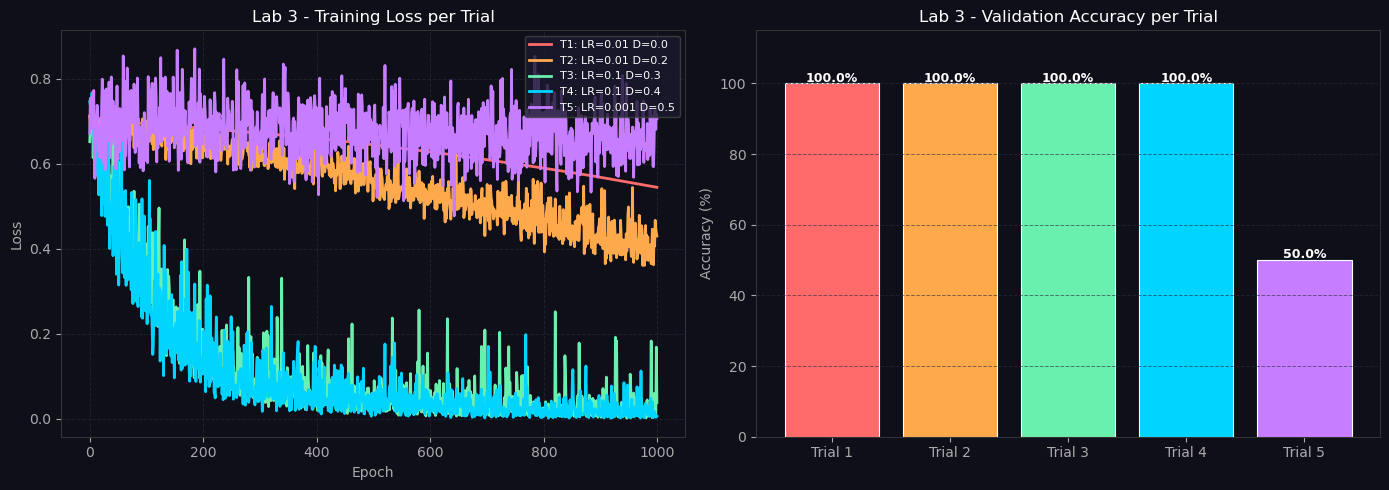

In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

trials = [
    {'lr':0.01, 'units':32, 'batch':32, 'dropout':0.0},
    {'lr':0.01, 'units':64, 'batch':32, 'dropout':0.2},
    {'lr':0.1,  'units':64, 'batch':64, 'dropout':0.3},
    {'lr':0.1,  'units':128,'batch':16, 'dropout':0.4},
    {'lr':0.001,'units':128,'batch':64, 'dropout':0.5},
]

def get_model(units, dropout):
    return nn.Sequential(
        nn.Linear(2, units), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(units, 1), nn.Sigmoid()
    )

results = []
all_losses = []

for i, t in enumerate(trials):
    model = get_model(t['units'], t['dropout'])
    criterion = nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=t['lr'])
    losses = []

    for epoch in range(1000):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    with torch.no_grad():
        preds = (model(X) >= 0.5).float()
        val_acc = (preds == y).float().mean().item() * 100

    overfit = "Yes" if losses[-1] < 0.1 and val_acc < 80 else "No"
    results.append({'trial': i+1, 'loss': losses[-1], 'acc': val_acc, 'overfit': overfit})
    all_losses.append(losses)

    print(f"Trial {i+1} | LR={t['lr']} Units={t['units']} Batch={t['batch']} Dropout={t['dropout']} | Loss={losses[-1]:.4f} | Acc={val_acc:.1f}% | Overfit={overfit}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')
colors = ['#ff6b6b','#ffa94d','#69f0ae','#00d4ff','#c77dff']

ax1 = axes[0]
ax1.set_facecolor('#0f0f1a')
for i, losses in enumerate(all_losses):
    t = trials[i]
    ax1.plot(losses, color=colors[i], linewidth=2,
             label=f"T{i+1}: LR={t['lr']} D={t['dropout']}")
ax1.set_title('Lab 3 - Training Loss per Trial', color='white', fontsize=12)
ax1.set_xlabel('Epoch', color='#aaa')
ax1.set_ylabel('Loss', color='#aaa')
ax1.tick_params(colors='#aaa')
ax1.grid(color='#2a2a3d', linestyle='--', linewidth=0.7, alpha=0.6)
ax1.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=8)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

ax2 = axes[1]
ax2.set_facecolor('#0f0f1a')
trial_labels = [f"Trial {r['trial']}" for r in results]
accs = [r['acc'] for r in results]
bars = ax2.bar(trial_labels, accs, color=colors, edgecolor='white', linewidth=0.8)
for bar, r in zip(bars, results):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{r['acc']:.1f}%", ha='center', color='white', fontsize=9, fontweight='bold')
ax2.set_title('Lab 3 - Validation Accuracy per Trial', color='white', fontsize=12)
ax2.set_ylabel('Accuracy (%)', color='#aaa')
ax2.set_ylim(0, 115)
ax2.tick_params(colors='#aaa')
ax2.grid(axis='y', color='#2a2a3d', linestyle='--', linewidth=0.7, alpha=0.6)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('lab3_gridsearch.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

LAB4 MNIST DNN IMPLEMENTATION

100%|██████████| 9.91M/9.91M [00:17<00:00, 573kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 94.0kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 383kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.81MB/s]


Epoch 1/5 | Train Loss=0.3517 Acc=89.35% | Val Loss=0.2106 Acc=93.21%
Epoch 2/5 | Train Loss=0.1723 Acc=94.74% | Val Loss=0.1615 Acc=94.95%
Epoch 3/5 | Train Loss=0.1295 Acc=96.02% | Val Loss=0.1043 Acc=96.71%
Epoch 4/5 | Train Loss=0.1079 Acc=96.68% | Val Loss=0.1123 Acc=96.32%
Epoch 5/5 | Train Loss=0.0933 Acc=97.03% | Val Loss=0.1064 Acc=96.69%


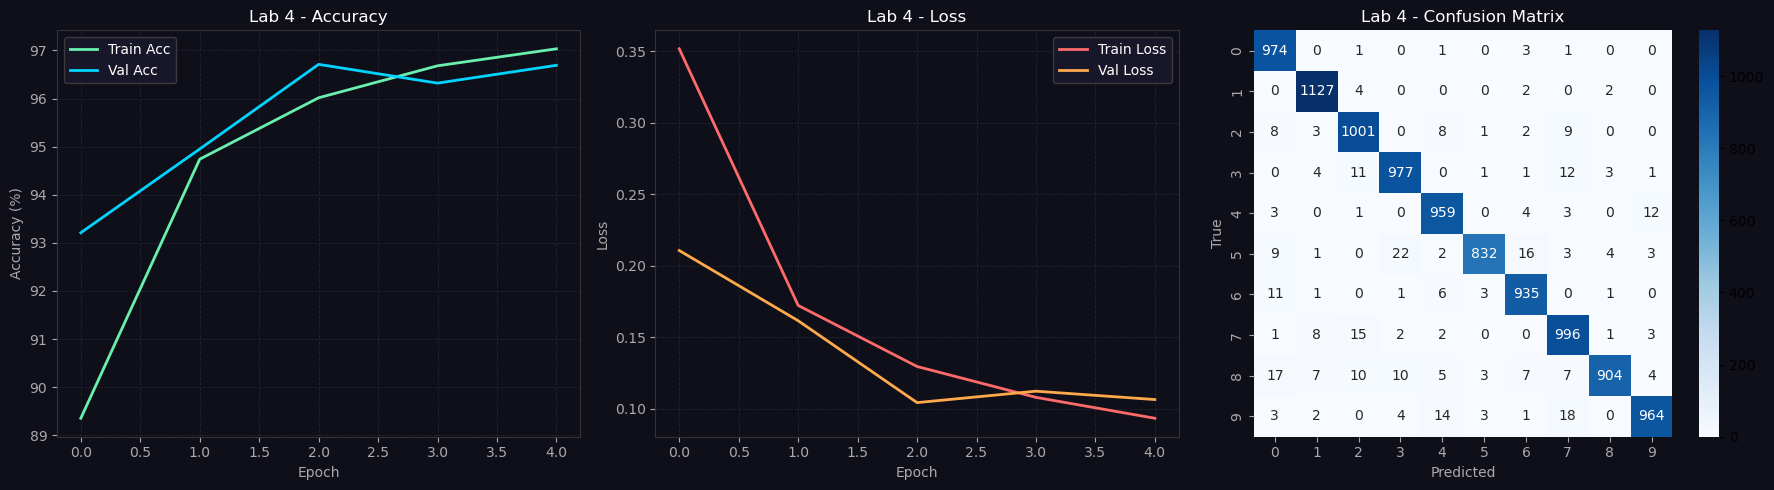

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_acc_list  = []
train_loss_list = []
val_acc_list    = []
val_loss_list   = []

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total * 100
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            val_loss  += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total  += labels.size(0)

    val_loss = val_loss / len(test_loader)
    val_acc  = val_correct / val_total * 100
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss={train_loss:.4f} Acc={train_acc:.2f}% | Val Loss={val_loss:.4f} Acc={val_acc:.2f}%")

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images).argmax(1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

ax1 = axes[0]
ax1.set_facecolor('#0f0f1a')
ax1.plot(train_acc_list, color='#69f0ae', linewidth=2, label='Train Acc')
ax1.plot(val_acc_list,   color='#00d4ff', linewidth=2, label='Val Acc')
ax1.set_title('Lab 4 - Accuracy', color='white', fontsize=12)
ax1.set_xlabel('Epoch', color='#aaa')
ax1.set_ylabel('Accuracy (%)', color='#aaa')
ax1.tick_params(colors='#aaa')
ax1.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')
ax1.grid(color='#2a2a3d', linestyle='--', linewidth=0.7, alpha=0.6)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

ax2 = axes[1]
ax2.set_facecolor('#0f0f1a')
ax2.plot(train_loss_list, color='#ff6b6b', linewidth=2, label='Train Loss')
ax2.plot(val_loss_list,   color='#ffa94d', linewidth=2, label='Val Loss')
ax2.set_title('Lab 4 - Loss', color='white', fontsize=12)
ax2.set_xlabel('Epoch', color='#aaa')
ax2.set_ylabel('Loss', color='#aaa')
ax2.tick_params(colors='#aaa')
ax2.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')
ax2.grid(color='#2a2a3d', linestyle='--', linewidth=0.7, alpha=0.6)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

ax3 = axes[2]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=range(10), yticklabels=range(10))
ax3.set_title('Lab 4 - Confusion Matrix', color='white', fontsize=12)
ax3.set_xlabel('Predicted', color='#aaa')
ax3.set_ylabel('True', color='#aaa')
ax3.tick_params(colors='#aaa')

plt.tight_layout()
plt.savefig('lab4_pytorch_mnist.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()